In [35]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

## run simulations


[0.2 0.4 0.6 0.8]


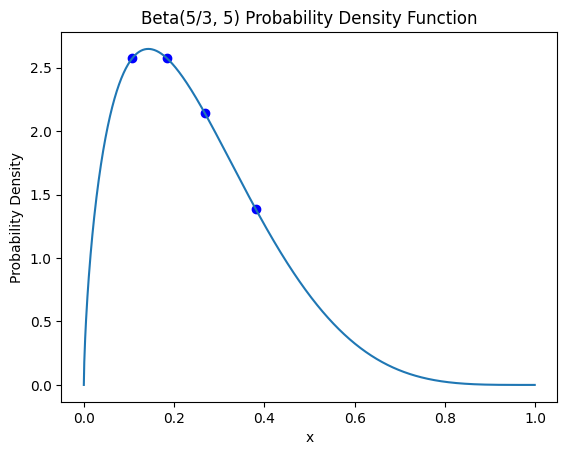

'0.11 0.18 0.27 0.38'

In [36]:
import subprocess
import os

import numpy as np
import scipy
from scipy.stats import beta
import numpy as np

n_guides = 4
quantiles = np.linspace(0, 1, n_guides + 2)[1:-1]
print(quantiles)
beta_samples = scipy.stats.beta.ppf(quantiles, 5 / 3, 5)

x = np.arange(0, 1, 0.001)
pdf = beta.pdf(x, 5 / 3, 5)

plt.plot(x, pdf)
plt.xlabel("x")
plt.ylabel("Probability Density")
plt.title("Beta(5/3, 5) Probability Density Function")

plt.scatter(beta_samples, beta.pdf(beta_samples, 5 / 3, 5), color="blue")
plt.show()

efficiency = ' '.join(beta_samples.round(2).astype(str))
efficiency

In [ ]:
import subprocess
import os

import numpy as np
import scipy
from scipy.stats import beta
import numpy as np

n_guides = 4
quantiles = np.linspace(0, 1, n_guides + 2)[1:-1]
print(quantiles)
beta_samples = scipy.stats.beta.ppf(quantiles, 5 / 3, 5)

x = np.arange(0, 1, 0.001)
pdf = beta.pdf(x, 5, 2)

plt.plot(x, pdf)
plt.xlabel("x")
plt.ylabel("Probability Density")
plt.title("Beta(5/3, 5) Probability Density Function")

plt.scatter(beta_samples, beta.pdf(beta_samples, 5 / 3, 5), color="blue")
plt.show()

efficiency = " ".join(beta_samples.round(2).astype(str))
efficiency

In [37]:
cmd = ["python", "/Users/ljb80/Projects/perturbo/src/perturbo/_jax_module.py"]
base_args = str.split(
    f"--n_control 1000 --n_perturbed 400 --n_guides {n_guides} --log2_fc -2.0 --gene_mean 2.0 --gene_disp 10.0 --efficiency {efficiency} "
)
output_dir = "data/4_guide_simulation"
# if not os.path.isdir(output_dir):
args_new = ["--output_dir", output_dir]
args = base_args + args_new
subprocess.run(cmd + args)

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


Simulating data with parameters:
# guides: 4
# control cells: 1000
# perturbed cells: 400
gene mean, dispersion: 2.00, 10.00
log_2 fold change: -2.0
guide efficiency: [0.11, 0.18, 0.27, 0.38]


sample: 100%|██████████| 2000/2000 [00:04<00:00, 435.18it/s, 15 steps of size 4.12e-01. acc. prob=0.91]


CompletedProcess(args=['python', '/Users/ljb80/Projects/perturbo/src/perturbo/_jax_module.py', '--n_control', '1000', '--n_perturbed', '400', '--n_guides', '4', '--log2_fc', '-2.0', '--gene_mean', '2.0', '--gene_disp', '10.0', '--efficiency', '0.11', '0.18', '0.27', '0.38', '--output_dir', 'data/4_guide_simulation'], returncode=0)

## load results


In [38]:
# for k in ["log2_fold_change", "mean", "dispersion"]:
# k = "log2_fold_change"


def get_simulation_df(data_dir, k):
    """Read the MCMC and SVI posterior samples from data_dir and return a combined DataFrame for the key k."""
    mcmc_file = f"{data_dir}/mcmc.npz"
    svi_file = f"{data_dir}/svi.npz"
    mcmc_npz = np.load(mcmc_file)
    svi_npz = np.load(svi_file)

    mcmc_df = pd.DataFrame({k: mcmc_npz[k].squeeze(), "method": "MCMC"})
    svi_df = pd.DataFrame({k: svi_npz[k].squeeze(), "method": "SVI"})
    df = pd.concat((mcmc_df, svi_df))
    return df


def get_efficiency_df(data_dir):
    """Read the MCMC and SVI posterior samples from data_dir and return a combined DataFrame for the key k."""
    mcmc_file = f"{data_dir}/mcmc.npz"
    svi_file = f"{data_dir}/svi.npz"
    mcmc_npz = np.load(mcmc_file)
    svi_npz = np.load(svi_file)

    mcmc_data = mcmc_npz["efficiency"].squeeze()
    n_guides = mcmc_data.shape[1]
    guide_names = [f"guide_{i+1}" for i in range(n_guides)]
    mcmc_df = pd.DataFrame(mcmc_npz["efficiency"].squeeze(), columns=guide_names).assign(method="MCMC")
    svi_df = pd.DataFrame(svi_npz["efficiency"].squeeze(), columns=guide_names).assign(method="SVI")
    # mcmc_df = pd.DataFramepd.DataFrame({k: mcmc_npz[k].squeeze(), "method": "MCMC"})
    # svi_df = pd.DataFrame({k: svi_npz[k].squeeze(), "method": "SVI"})
    df = pd.concat((mcmc_df, svi_df))
    return df


output_dir = "data/4_guide_simulation/"
efficiency_df = get_simulation_df(output_dir, "log2_fold_change")


In [39]:
lfc_df = get_efficiency_df(output_dir)

In [40]:
# dfs = []
#     output_dir = f"data/run_efficiency_{efficiency:0.1f}"
#     lfc_df = get_simulation_df(output_dir, "log2_fold_change")
#     efficiency_df = get_efficiency_df(output_dir)
lfc_all_df = pd.concat([lfc_df.drop(columns="method"), efficiency_df], axis=1).assign(efficiency=efficiency)
lfc_all_df
#     dfs.append(combined_df)
# lfc_all_df = pd.concat(dfs)

,guide_1,guide_2,guide_3,guide_4,log2_fold_change,method,efficiency
0,0.290389,0.592459,0.382606,0.859918,-1.040839,MCMC,0.11 0.18 0.27 0.38
1,0.240079,0.422959,0.622982,0.975090,-0.696195,MCMC,0.11 0.18 0.27 0.38
2,0.595741,0.295638,0.528258,0.927697,-0.591199,MCMC,0.11 0.18 0.27 0.38
3,0.694728,0.560143,0.498381,0.949646,-0.606888,MCMC,0.11 0.18 0.27 0.38
4,0.406540,0.895202,0.613714,0.559756,-0.635847,MCMC,0.11 0.18 0.27 0.38
...,...,...,...,...,...,...,...
995,0.469603,0.882204,0.792670,0.895548,-0.723944,SVI,0.11 0.18 0.27 0.38
996,0.418548,0.761293,0.611462,0.945799,-0.689610,SVI,0.11 0.18 0.27 0.38
997,0.849759,0.680026,0.838028,0.980726,-0.723137,SVI,0.11 0.18 0.27 0.38
998,0.441541,0.720789,0.875989,0.977206,-0.717907,SVI,0.11 0.18 0.27 0.38


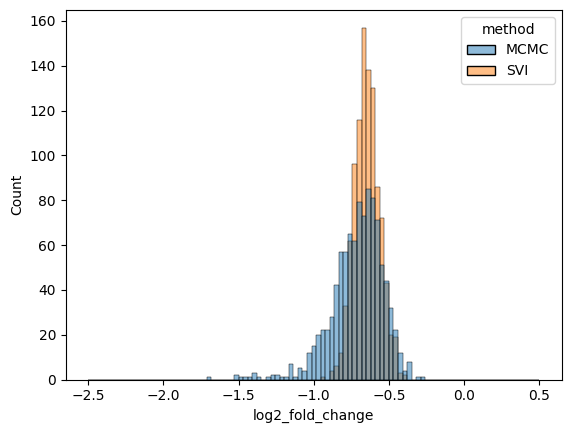

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

n_bins = 100

# g = sns.FacetGrid(lfc_all_df hue="method", height=3, aspect=2, sharex=False)
sns.histplot(lfc_all_df, x="log2_fold_change", hue="method", alpha=0.5, bins=np.linspace(-2.5, 0.5, n_bins))
# Add a legend
# g.add_legend()

plt.show()

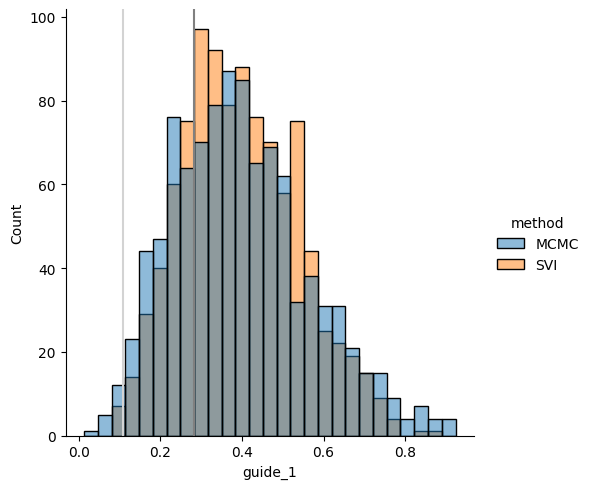

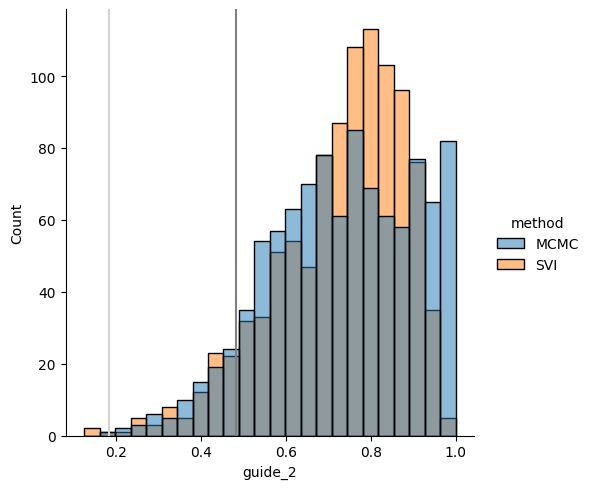

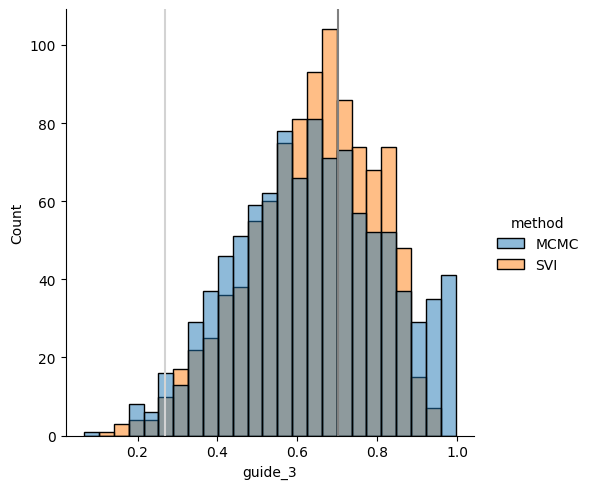

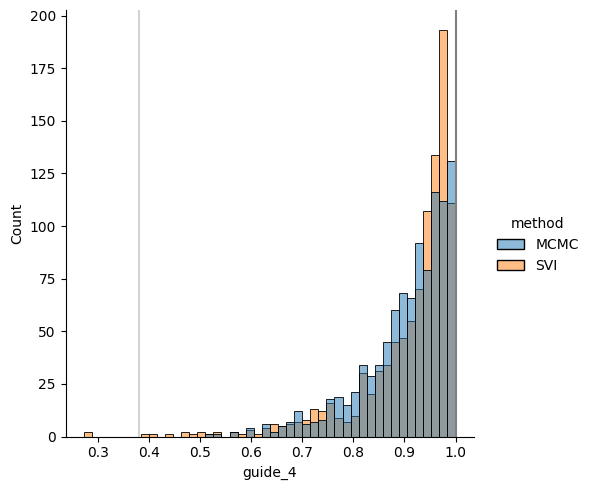

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

n_bins = 100


# g = sns.FacetGrid(lfc_all_df, row="efficiency", hue="method", height=3, aspect=2, sharex=False)
for i in range(n_guides):
    sns.displot(lfc_all_df, x=f"guide_{i+1}", alpha=0.5, hue="method")
    plt.axvline(beta_samples[i], color="lightgrey")
    plt.axvline(beta_samples[i] / beta_samples.max(), color="grey")
    plt.show()

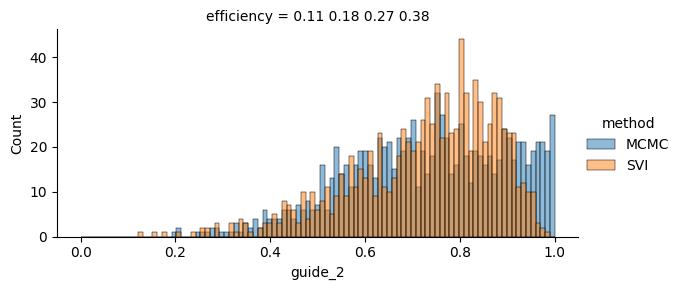

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

n_bins = 100

g = sns.FacetGrid(lfc_all_df, row="efficiency", hue="method", height=3, aspect=2, sharex=False)
g.map(sns.histplot, "guide_2", alpha=0.5, bins=np.linspace(0, 1, n_bins))
# Add a legend
g.add_legend()

plt.show()

In [44]:
lfc_all_df = lfc_all_df.assign(scaled_lfc=lambda x: x["log2_fold_change"] * x["guide_2"])
lfc_all_df

,guide_1,guide_2,guide_3,guide_4,log2_fold_change,method,efficiency,scaled_lfc
0,0.290389,0.592459,0.382606,0.859918,-1.040839,MCMC,0.11 0.18 0.27 0.38,-0.616655
1,0.240079,0.422959,0.622982,0.975090,-0.696195,MCMC,0.11 0.18 0.27 0.38,-0.294462
2,0.595741,0.295638,0.528258,0.927697,-0.591199,MCMC,0.11 0.18 0.27 0.38,-0.174781
3,0.694728,0.560143,0.498381,0.949646,-0.606888,MCMC,0.11 0.18 0.27 0.38,-0.339944
4,0.406540,0.895202,0.613714,0.559756,-0.635847,MCMC,0.11 0.18 0.27 0.38,-0.569211
...,...,...,...,...,...,...,...,...
995,0.469603,0.882204,0.792670,0.895548,-0.723944,SVI,0.11 0.18 0.27 0.38,-0.638666
996,0.418548,0.761293,0.611462,0.945799,-0.689610,SVI,0.11 0.18 0.27 0.38,-0.524995
997,0.849759,0.680026,0.838028,0.980726,-0.723137,SVI,0.11 0.18 0.27 0.38,-0.491753
998,0.441541,0.720789,0.875989,0.977206,-0.717907,SVI,0.11 0.18 0.27 0.38,-0.517460


In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

n_bins = 100
lfc_all_df = lfc_all_df.assign(
    scaled_lfc_1=lambda x: x["log2_fold_change"] * x["guide_1"],
    scaled_lfc_2=lambda x: x["log2_fold_change"] * x["guide_2"],
)
lfc_all_df

,guide_1,guide_2,guide_3,guide_4,log2_fold_change,method,efficiency,scaled_lfc,scaled_lfc_1,scaled_lfc_2
0,0.290389,0.592459,0.382606,0.859918,-1.040839,MCMC,0.11 0.18 0.27 0.38,-0.616655,-0.302249,-0.616655
1,0.240079,0.422959,0.622982,0.975090,-0.696195,MCMC,0.11 0.18 0.27 0.38,-0.294462,-0.167142,-0.294462
2,0.595741,0.295638,0.528258,0.927697,-0.591199,MCMC,0.11 0.18 0.27 0.38,-0.174781,-0.352201,-0.174781
3,0.694728,0.560143,0.498381,0.949646,-0.606888,MCMC,0.11 0.18 0.27 0.38,-0.339944,-0.421622,-0.339944
4,0.406540,0.895202,0.613714,0.559756,-0.635847,MCMC,0.11 0.18 0.27 0.38,-0.569211,-0.258497,-0.569211
...,...,...,...,...,...,...,...,...,...,...
995,0.469603,0.882204,0.792670,0.895548,-0.723944,SVI,0.11 0.18 0.27 0.38,-0.638666,-0.339966,-0.638666
996,0.418548,0.761293,0.611462,0.945799,-0.689610,SVI,0.11 0.18 0.27 0.38,-0.524995,-0.288635,-0.524995
997,0.849759,0.680026,0.838028,0.980726,-0.723137,SVI,0.11 0.18 0.27 0.38,-0.491753,-0.614493,-0.491753
998,0.441541,0.720789,0.875989,0.977206,-0.717907,SVI,0.11 0.18 0.27 0.38,-0.517460,-0.316986,-0.517460


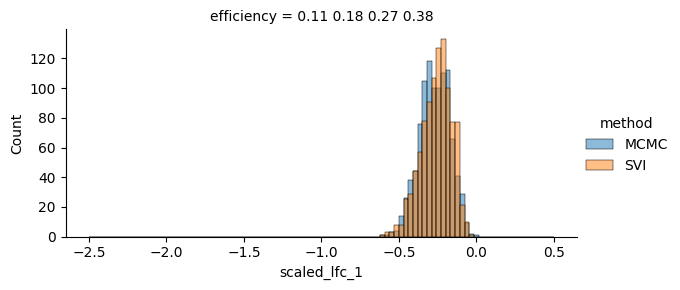

In [46]:
g = sns.FacetGrid(lfc_all_df, row="efficiency", hue="method", height=3, aspect=2, sharex=False)
g.map(sns.histplot, "scaled_lfc_1", alpha=0.5, bins=np.linspace(-2.5, 0.5, n_bins))
# Add a legend
g.add_legend()

plt.show()